# Théorème de Marcchenko Pastur 

0.803231049452779


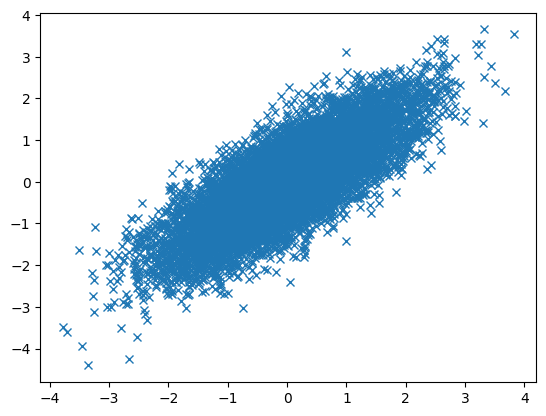

In [39]:
import numpy as np
import numpy.random as npr 
import matplotlib.pyplot as plt

N=10000
rho=0.8

X=npr.normal(0,1,N) # X= G_1
Y=rho*X + np.sqrt(1-rho**2)*npr.normal(0,1,N) # Y= rho*G_1 +  sqrt(1-rho^2)*G_2,   G_1 indep. G_2

# XY= rho*G_1*G_1 + sqrt(1-rho^2)*G_1*G_2
# EXY= rho*E(G_1^2)=rho
# cov(X,Y)=rho 

# Deuxième méthode Cholesky :
# Gamma=[1,rho],[rho,1]
# A=np.linalg.cholesky(Gamma) matrice triangulaire inférieure
# G=np.normal(0,1,(2,N)) # G=(G_1,G_2)
# Z=np.dot(A,G)# Z=(X,Y)

# Corr(X,Y)=Cov(X,Y)/(sqrt(Var(X))*sqrt(Var(Y)) )

plt.plot(X,Y,'x')

# Méthodes empirique Monte Carlo pour le calcul de la covariance
cov_XY=np.mean(X*Y)-np.mean(X)*np.mean(Y)
print(cov_XY)

Soit $X$ une matrice aléatoire de taille  $M\times N$ dont les entrées sont des variables i.i.d gaussiennes de moyennes 0 et variances $\sigma^2<+\infty$. Soit $H=\frac{1}{N}XX^{\top}$ et $M,N\to+\infty$ de sorte que le rapport $M/N\to q\in(0,+\infty)$. Alors la densit\'e des valeurs propres de la matrice de corrélation de $X$ est :


\begin{equation}
\rho(x)=\frac{1}{2\pi\sigma^2}\frac{\sqrt{(\lambda_+-x)(x-\lambda_-)}}{xq}\times 1_{x\in[\lambda_-,\lambda_+]}
\end{equation}
avec 
\begin{equation}
\lambda_+=\sigma^2(1+\sqrt{q})^2, \quad\mbox{ and }\quad \lambda_-=\sigma^2(1-\sqrt{q})^2.
\end{equation}

## Quelques fonctions utiles pour python

In [40]:
import numpy as np

A=np.diag((1, 2, 3))
print(A)
w, v = np.linalg.eig(A) # eigenvalues and eigenvectors
print(w) 
print(v)

[[1 0 0]
 [0 2 0]
 [0 0 3]]
[1. 2. 3.]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [41]:
def myfunc(a, b):
    "Return a-b if a>b, otherwise return a+b"
    if a > b:
         return a - b
    else:
        return a + b
    
#a=myfunc([1,2], 3)
#print(a)

f=np.vectorize(myfunc)    
f([1, 2, 3, 4], 2)



array([3, 4, 1, 2])

In [42]:
#try:
    # Bloc à essayer
#except:
    # Bloc qui sera exécuté en cas d'erreur
    
    
    

## Matrices de Wishart 

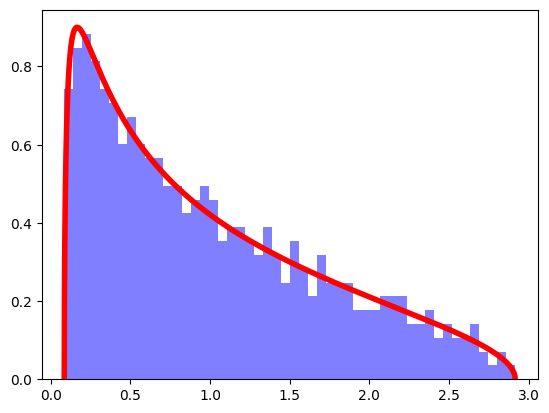

In [52]:
import matplotlib.pyplot as plt
    
# Definition of the Marchenko-Pastur density
def marchenko_pastur_pdf(x,Q,sigma=1):
     
    #Q number of lines/number of columns converges to Y
    b = (sigma*(1 + np.sqrt(Q)))**2  # Largest eigenvalue
    a = (sigma*(1 - np.sqrt(Q)))**2  # Smallest eigenvalue
    return (np.sqrt((b-x)*(x-a)) * ((x>=a) & (x<=b))) / (2*np.pi*sigma*sigma*x*Q)

    
def compare_eigenvalue_distribution(correlation_matrix, Q, sigma=1,  show_top = True):
    
    e,ev= np.linalg.eig(correlation_matrix) #compute eigenvalues of the correlation matrix
               

    x_min = .0001 if (sigma*(1 - np.sqrt(Q)))**2 < .0001 else (sigma*(1 - np.sqrt(Q)))**2
    x_max = (sigma*(1 + np.sqrt(Q)))**2
    
    
    

    bins = 50
    #plot histogram
    plt.hist(e, bins=bins, range=(x_min, x_max), density=True, alpha=0.5, color='b')
    #density=True  efféctifs normalisés pour récupérer une approximation de la densité
   
    # Plot the theoretical density
    f = np.vectorize(lambda x: marchenko_pastur_pdf(x, Q, sigma))
    # f = ? 
        
        
    x = np.linspace(x_min,x_max,5000)
    plt.plot(x,f(x), linewidth=4, color = 'r')

#fin de la fonction
    
# Create the correlation matrix and find the eigenvalues
N= 500  #rows
T= 1000 # columns 
X= np.random.normal(0,1,size=(N,T))# Wishart Matrix dont les entrées son N(0,1) unidimensionnelles

H = np.corrcoef(X) # H=XX^T/N il faut diviser par les variance pour avoir la coreelation

#print(cor)
#Correlation matrix
# 
Q= N/T
compare_eigenvalue_distribution(H, Q, sigma=1, show_top=True)

In [ ]:
import numpy as np
import pandas as pd
import datetime as dt
from pandas_datareader import DataReader
import yfinance as yf
    
np.random.seed(777) #Jackpot
size = 20
    
start, end = dt.datetime(2012, 1, 1), dt.datetime(2013, 12, 31)
tickers = pd.read_csv('yahoo_tickers_2010.csv', header=None)[0]
tickers = np.random.choice(tickers.values, size=size, replace=False) # Choose a random set of headers
print(tickers)
prices = pd.DataFrame()
for ticker in tickers:
    try:
        prices[ticker] = yf.download(ticker,'yahoo', start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')).loc[:,'Close']
    except Exception as e:
        pass               #ignor exceptions
    
   
returns = prices.pct_change() 
#Computes the percentage change from the immediately previous row by default. 
#This is useful in comparing the percentage of change in a time series of elements.
#example :
#s = pd.Series([100, 150, 180])
#print(s)
#print(s.pct_change())
returns = returns.iloc[1:, :]# Remove first row of NA's generated by pct_changes()
                            #iloc gets rows (or columns) at particular positions in the index 
                            #(so it only takes integers).
returns.dropna(axis = 1, thresh=len(returns.index)/2, inplace=True) # Drop stocks with over half the data missing
returns.dropna(axis = 0, thresh=len(returns.columns), inplace=True) # Drop days without data for all stocks


tickers = returns.columns # Remove tickers that were dropped

returns.shape

C:\Users\lione\AppData\Local\Temp\ipykernel_26712\440845266.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices[ticker] = yf.download(ticker,'yahoo', start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')).loc[:,'Close']
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BANSWRAS.NS']: ValueError("time data 'yahoo' does not match format '%Y-%m-%d'")
C:\Users\lione\AppData\Local\Temp\ipykernel_26712\440845266.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices[ticker] = yf.download(ticker,'yahoo', start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')).loc[:,'Close']
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['NSN.DE']: ValueError("time data 'yahoo' does not match format '%Y-%m-%d'")
C:\Users\lione\AppData\Local\Temp\ipykernel_26712\440845266.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to T

['BANSWRAS.NS' 'NSN.DE' 'ETEC.OB' 'ALRN' 'CE2.DE' 'TTM.V' 'SUL.AX' 'BFK'
 'GDF-H.V' 'S10.SI' 'RHL.AX' 'H' 'SUNPHADV.BO' 'SWS' 'AFFW.OB' 'K90.DE'
 'KB2.DE' 'GOE.PA' 'TCN.AX' 'BUSE']


C:\Users\lione\AppData\Local\Temp\ipykernel_26712\440845266.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices[ticker] = yf.download(ticker,'yahoo', start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')).loc[:,'Close']
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['H']: ValueError("time data 'yahoo' does not match format '%Y-%m-%d'")
C:\Users\lione\AppData\Local\Temp\ipykernel_26712\440845266.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices[ticker] = yf.download(ticker,'yahoo', start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')).loc[:,'Close']
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SUNPHADV.BO']: ValueError("time data 'yahoo' does not match format '%Y-%m-%d'")
C:\Users\lione\AppData\Local\Temp\ipykernel_26712\440845266.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
 

(0, 20)

In [62]:
print(returns.columns)

Index(['BANSWRAS.NS', 'NSN.DE', 'ETEC.OB', 'ALRN', 'CE2.DE', 'TTM.V', 'SUL.AX',
       'BFK', 'GDF-H.V', 'S10.SI', 'RHL.AX', 'H', 'SUNPHADV.BO', 'SWS',
       'AFFW.OB', 'K90.DE', 'KB2.DE', 'GOE.PA', 'TCN.AX', 'BUSE'],
      dtype='object')


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 

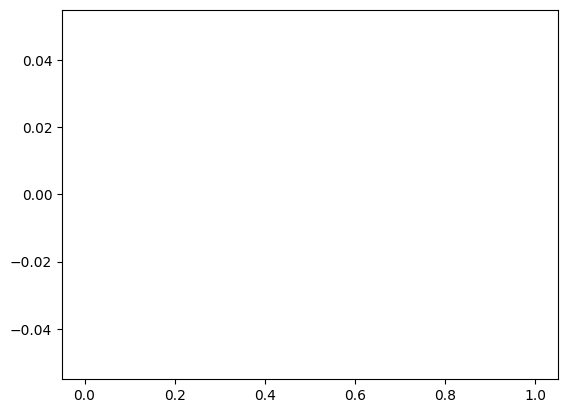

In [63]:


import numpy as np
    
log_returns = returns.apply(lambda x : np.log(x+1)) # compute the log returns pct=(R_2-R_1)/R_1;  log(pct+1)=log(R_2/R_1)

# Faites un histogramme des log_returns 

#print(returns.columns)
plt.hist(log_returns.values.flatten(), bins=100)




#print(log_returns)





In [56]:
#Compléter en appliquant le theoreme de Marchenko Pastur

T, N = returns.shape
print(T,N)
Q=N/T
    
correlation_matrix = log_returns.interpolate().corr() #If Nan do interpolation



compare_eigenvalue_distribution(correlation_matrix, Q)

0 0


ZeroDivisionError: division by zero

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fae6e0f9ad0>,
      dtype=object)

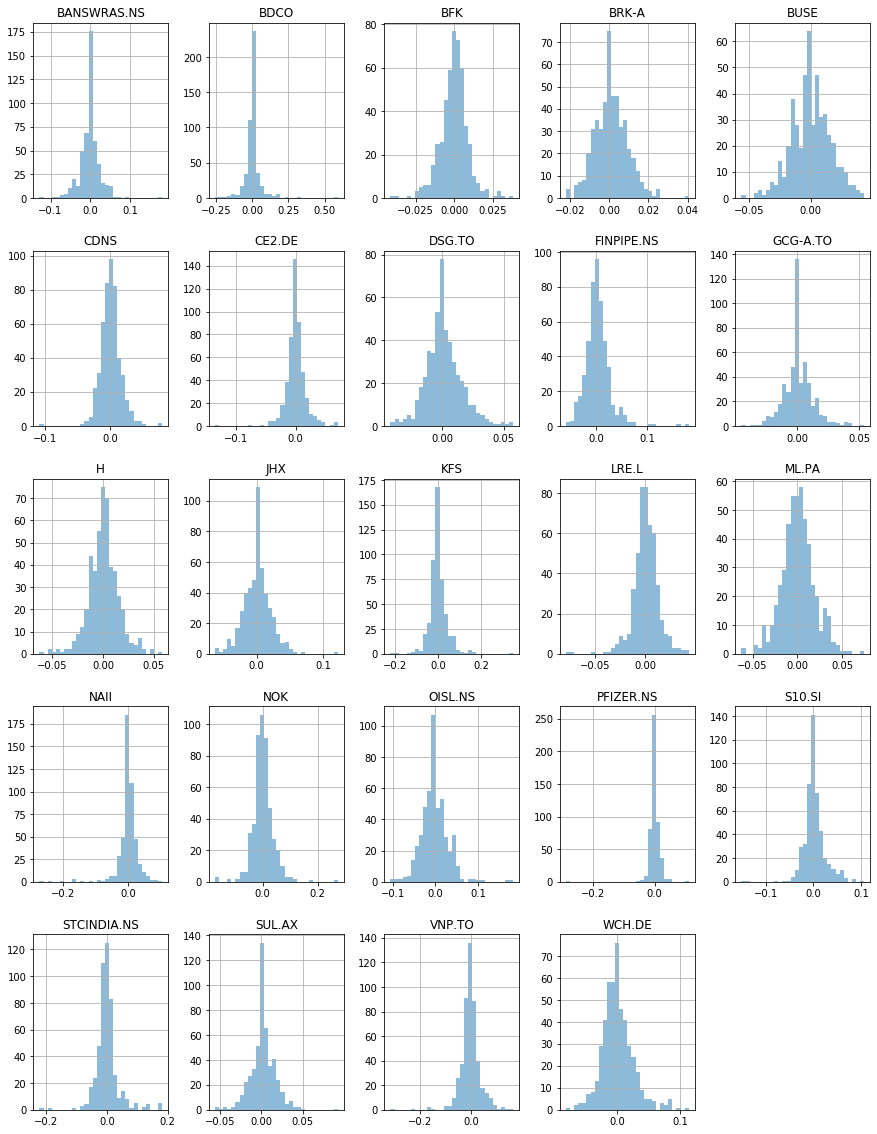

In [ ]:
indices= ['BANSWRAS.NS','BDCO','BFK', 'BRK-A', 'CDNS', 'BUSE','CE2.DE', 'DSG.TO', 'FINPIPE.NS','GCG-A.TO' ,'H', 'JHX','KFS','ML.PA','LRE.L','NAII', 'OISL.NS', 'NOK','PFIZER.NS',  'S10.SI','STCINDIA.NS', 'SUL.AX', 'VNP.TO', 'WCH.DE'] 

new_log_returns= log_returns[indices]

new_log_returns.hist(bins=30,alpha=0.5,figsize=(15,20))

491 24


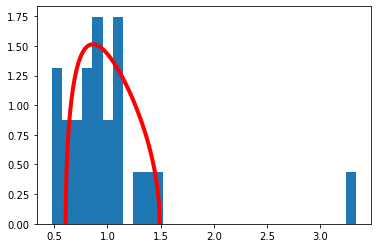

In [ ]:
T, N = new_log_returns.shape
print(T,N)
Q=N/T
    
new_correlation_matrix = new_log_returns.interpolate().corr() #If Nan do interpolation



compare_eigenvalue_distribution(new_correlation_matrix, Q)

# 24 indice c'est trop petit par rapport 491 